<a href="https://colab.research.google.com/github/rafibusono/pengolahan_citra_ti2c/blob/main/Jobsheet_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Praktikum 1 – Jarak Euclidean & Manhattan**

Euclidean:
Patch1 vs Patch2: 24.7650110983629
Patch1 vs Patch3: 5.0

Manhattan:
Patch1 vs Patch2: 936.4392156862746
Patch1 vs Patch3: 249.99999999999997


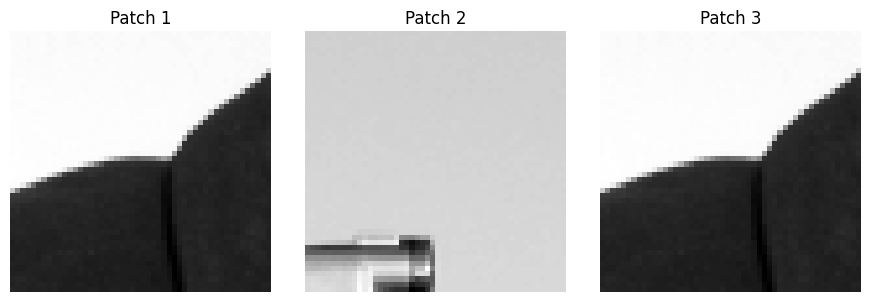

In [1]:
import numpy as np
from skimage import data, img_as_float
from scipy.spatial import distance
import matplotlib.pyplot as plt

# Ambil dua patch dari citra kamera
image = img_as_float(data.camera())
patch1 = image[100:150, 100:150]
patch2 = image[100:150, 300:350]
patch3 = np.clip(patch1 + 0.1, 0, 1)  # patch1 + noise

# Ubah patch ke bentuk vektor
vec1, vec2, vec3 = patch1.flatten(), patch2.flatten(), patch3.flatten()

# Hitung jarak
print("Euclidean:")
print("Patch1 vs Patch2:", distance.euclidean(vec1, vec2))
print("Patch1 vs Patch3:", distance.euclidean(vec1, vec3))

print("\nManhattan:")
print("Patch1 vs Patch2:", distance.cityblock(vec1, vec2))
print("Patch1 vs Patch3:", distance.cityblock(vec1, vec3))

# Visualisasi
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
for ax, patch, title in zip(axes, [patch1, patch2, patch3], ["Patch 1", "Patch 2", "Patch 3"]):
    ax.imshow(patch, cmap='gray')
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()


# **Praktikum 2 – Cosine Similarity (Histogram Warna)**

Cosine Similarity:
Image1 vs Image2: 0.8155681341106965
Image1 vs Image3: 1.0
Image1 vs Image4: 0.9999762411449648


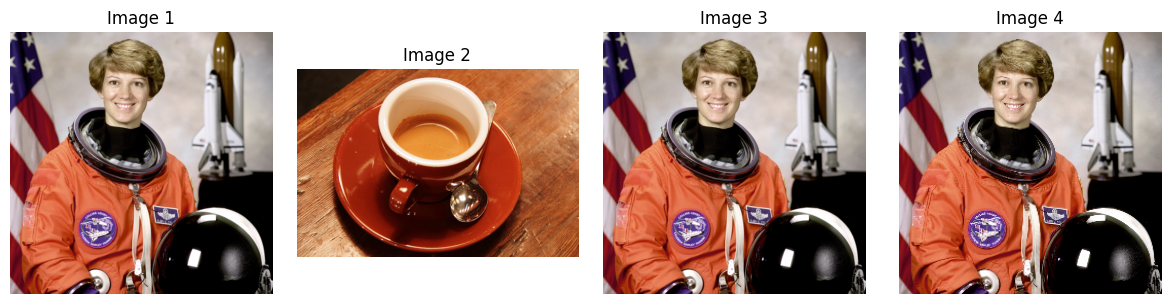

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_ubyte
from scipy.spatial import distance

def calculate_rgb_histogram(image, bins=16):
    img = img_as_ubyte(image)
    h_r = np.histogram(img[:, :, 0].ravel(), bins=bins, range=(0, 256))[0]
    h_g = np.histogram(img[:, :, 1].ravel(), bins=bins, range=(0, 256))[0]
    h_b = np.histogram(img[:, :, 2].ravel(), bins=bins, range=(0, 256))[0]
    hist = np.concatenate([h_r, h_g, h_b]).astype(float)
    return hist / hist.sum()

# Ambil citra
image1 = data.astronaut()
image2 = data.coffee()
image3 = data.astronaut()
image4 = image1[::2, ::2, :]

# Histogram
h1 = calculate_rgb_histogram(image1)
h2 = calculate_rgb_histogram(image2)
h3 = calculate_rgb_histogram(image3)
h4 = calculate_rgb_histogram(image4)

# Hitung Cosine Similarity
print("Cosine Similarity:")
print("Image1 vs Image2:", 1 - distance.cosine(h1, h2))
print("Image1 vs Image3:", 1 - distance.cosine(h1, h3))
print("Image1 vs Image4:", 1 - distance.cosine(h1, h4))

# Visualisasi
images = [image1, image2, image3, image4]
titles = ["Image 1", "Image 2", "Image 3", "Image 4"]
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for ax, img, title in zip(axes, images, titles):
    ax.imshow(img)
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()


# **Praktikum 3 – Structural Similarity Index (SSIM)**

SSIM Same: 1.0000
SSIM Noisy: 0.2950
SSIM Contrast: 0.9651
SSIM Blurred: 0.8027


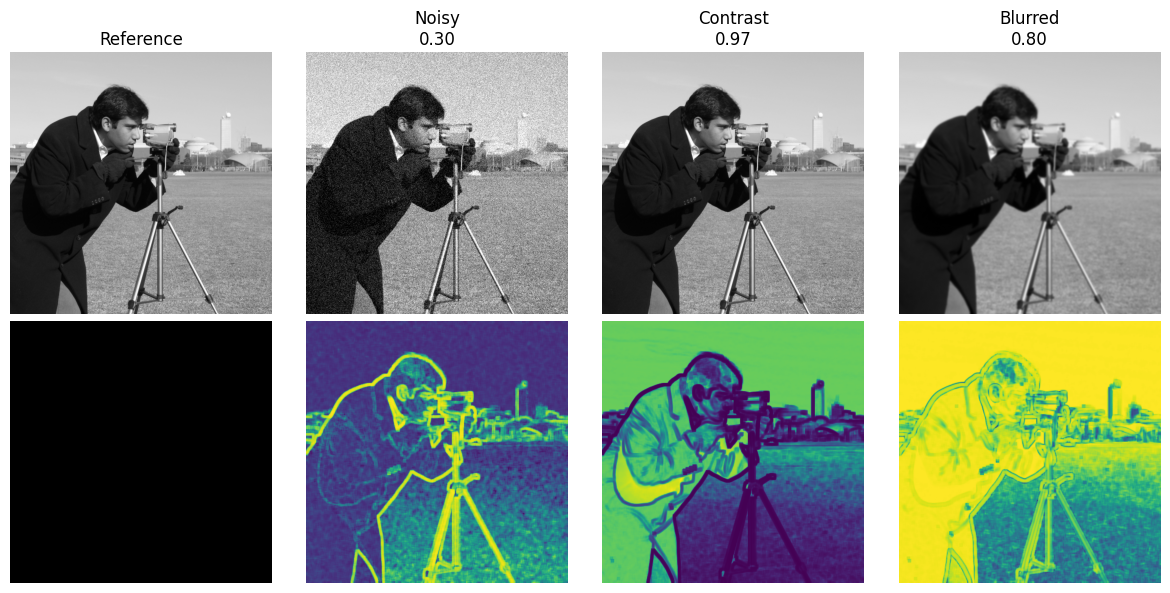

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float
from skimage.metrics import structural_similarity as ssim
from skimage.filters import gaussian
from skimage.util import random_noise

image_ref = img_as_float(data.camera())
image_same = image_ref.copy()
image_noisy = random_noise(image_ref, mode='gaussian', var=0.01)
image_contrast = np.clip(image_ref * 0.8, 0, 1)
image_blurred = gaussian(image_ref, sigma=1.5)

# Hitung SSIM
range_ = image_ref.max() - image_ref.min()
ssim_same, _ = ssim(image_ref, image_same, data_range=range_, full=True)
ssim_noisy, diff_noisy = ssim(image_ref, image_noisy, data_range=range_, full=True)
ssim_contrast, diff_contrast = ssim(image_ref, image_contrast, data_range=range_, full=True)
ssim_blurred, diff_blurred = ssim(image_ref, image_blurred, data_range=range_, full=True)

# Cetak nilai SSIM
print(f"SSIM Same: {ssim_same:.4f}")
print(f"SSIM Noisy: {ssim_noisy:.4f}")
print(f"SSIM Contrast: {ssim_contrast:.4f}")
print(f"SSIM Blurred: {ssim_blurred:.4f}")

# Tampilkan citra dan hasil SSIM
images = [image_ref, image_noisy, image_contrast, image_blurred]
diffs = [None, diff_noisy, diff_contrast, diff_blurred]
titles = ["Reference", f"Noisy\n{ssim_noisy:.2f}", f"Contrast\n{ssim_contrast:.2f}", f"Blurred\n{ssim_blurred:.2f}"]

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i in range(4):
    axes[0, i].imshow(images[i], cmap='gray')
    axes[0, i].set_title(titles[i])
    axes[0, i].axis('off')
    if i == 0:
        axes[1, i].imshow(np.zeros_like(image_ref), cmap='gray')
    else:
        axes[1, i].imshow(diffs[i], cmap='viridis')
    axes[1, i].axis('off')
plt.tight_layout()
plt.show()


# **Praktikum 4 – Template Matching**

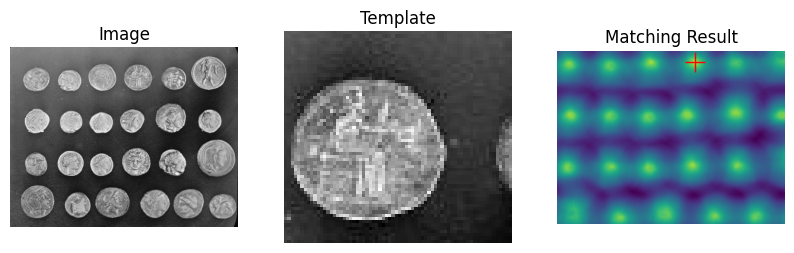

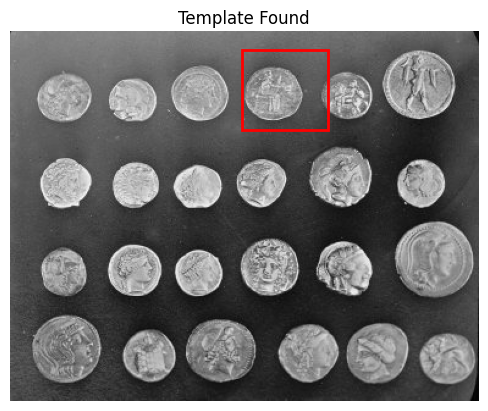

Template ditemukan pada koordinat: (190, 15)


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.feature import match_template

image = data.coins()
template = image[15:80, 190:260]
result = match_template(image, template)
ij = np.unravel_index(np.argmax(result), result.shape)
x, y = ij[::-1]

# Tampilkan hasil
fig, ax = plt.subplots(1, 3, figsize=(10, 4))
ax[0].imshow(image, cmap='gray')
ax[0].set_title('Image')
ax[1].imshow(template, cmap='gray')
ax[1].set_title('Template')
ax[2].imshow(result, cmap='viridis')
ax[2].plot(x, y, 'r+', markersize=15)
ax[2].set_title('Matching Result')
for a in ax:
    a.axis('off')

# Tampilkan lokasi pada citra asli
fig2, ax_main = plt.subplots()
ax_main.imshow(image, cmap='gray')
h, w = template.shape
rect = plt.Rectangle((x, y), w, h, edgecolor='r', facecolor='none', linewidth=2)
ax_main.add_patch(rect)
ax_main.set_title('Template Found')
ax_main.axis('off')
plt.show()

print(f"Template ditemukan pada koordinat: ({x}, {y})")


# **Praktikum 5 – CBIR (Content-Based Image Retrieval)**

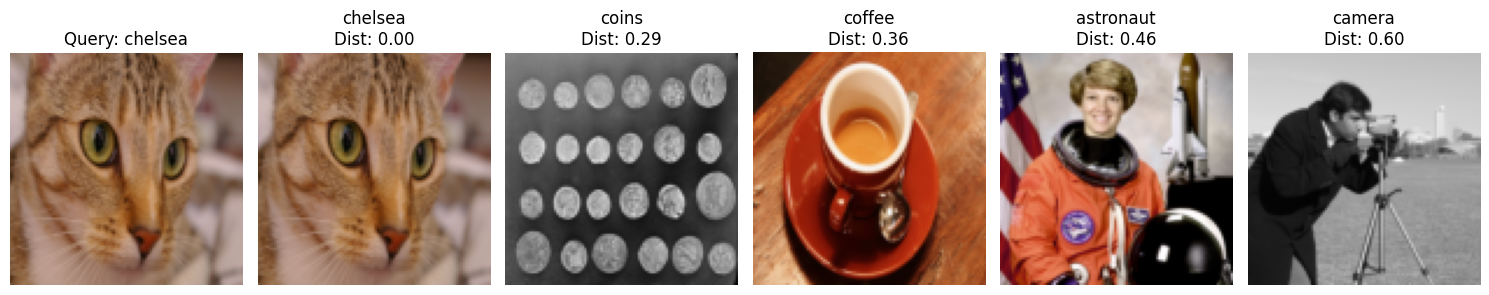

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, transform, img_as_float
from scipy.spatial import distance

def calculate_rgb_histogram(image, bins=16):
    from skimage import img_as_ubyte
    image = img_as_ubyte(image)
    h_r = np.histogram(image[:,:,0].ravel(), bins=bins, range=(0, 256))[0]
    h_g = np.histogram(image[:,:,1].ravel(), bins=bins, range=(0, 256))[0]
    h_b = np.histogram(image[:,:,2].ravel(), bins=bins, range=(0, 256))[0]
    hist = np.concatenate([h_r, h_g, h_b]).astype(float)
    return hist / hist.sum()

# Siapkan database citra
image_names = ["astronaut", "camera", "coffee", "coins", "chelsea"]
images = []
histograms = []

for name in image_names:
    img = getattr(data, name)()
    if img.ndim == 2:
        img = color.gray2rgb(img)
    img = transform.resize(img, (100, 100), anti_aliasing=True)
    images.append(img)
    histograms.append(calculate_rgb_histogram(img))

# Query image
query_name = "chelsea"
query_index = image_names.index(query_name)
query_image = images[query_index]
query_hist = histograms[query_index]

# Hitung jarak cosine
distances = [distance.cosine(query_hist, hist) for hist in histograms]

# Urutkan berdasarkan jarak
sorted_indices = np.argsort(distances)

# Tampilkan hasil
fig, axes = plt.subplots(1, len(images) + 1, figsize=(15, 3))
axes[0].imshow(query_image)
axes[0].set_title(f"Query: {query_name}")
axes[0].axis('off')

for rank, idx in enumerate(sorted_indices):
    ax = axes[rank + 1]
    ax.imshow(images[idx])
    ax.set_title(f"{image_names[idx]}\nDist: {distances[idx]:.2f}")
    ax.axis('off')

plt.tight_layout()
plt.show()


# **Tugas 1. Fitur Berbeda untuk CBIR**


Hasil CBIR berdasarkan rata-rata warna:
Rank 1: chelsea (Distance: 0.00)
Rank 2: astronaut (Distance: 0.05)
Rank 3: coffee (Distance: 0.18)
Rank 4: camera (Distance: 0.19)
Rank 5: coins (Distance: 0.21)


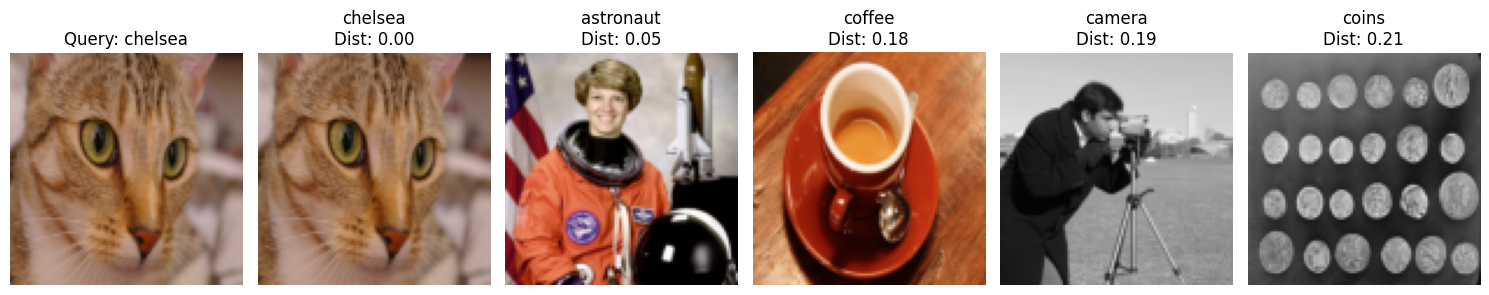

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, transform, img_as_float
from scipy.spatial import distance

# Fungsi menghitung mean warna RGB
def calculate_rgb_mean(image):
    if image.ndim == 2:  # Grayscale to RGB
        image = color.gray2rgb(image)
    mean_rgb = np.mean(image.reshape(-1, 3), axis=0)  # Rata-rata R, G, B
    return mean_rgb

# Dataset
image_names = ["astronaut", "camera", "coffee", "coins", "chelsea"]
images = []
features = []

for name in image_names:
    img = getattr(data, name)()
    if img.ndim == 2:
        img = color.gray2rgb(img)
    img = transform.resize(img, (100, 100), anti_aliasing=True)
    images.append(img)
    features.append(calculate_rgb_mean(img))

# Query image
query_name = "chelsea"
query_index = image_names.index(query_name)
query_image = images[query_index]
query_feature = features[query_index]

# Hitung jarak Euclidean antara mean warna
distances = [distance.euclidean(query_feature, feat) for feat in features]

# Urutkan berdasarkan jarak
sorted_indices = np.argsort(distances)

# Visualisasi hasil retrieval
fig, axes = plt.subplots(1, len(images) + 1, figsize=(15, 3))
axes[0].imshow(query_image)
axes[0].set_title(f"Query: {query_name}")
axes[0].axis('off')

print("\nHasil CBIR berdasarkan rata-rata warna:")
for i, idx in enumerate(sorted_indices):
    ax = axes[i + 1]
    ax.imshow(images[idx])
    ax.set_title(f"{image_names[idx]}\nDist: {distances[idx]:.2f}")
    ax.axis('off')
    print(f"Rank {i+1}: {image_names[idx]} (Distance: {distances[idx]:.2f})")

plt.tight_layout()
plt.show()


# **Tugas 4. Template Matching Invariant**

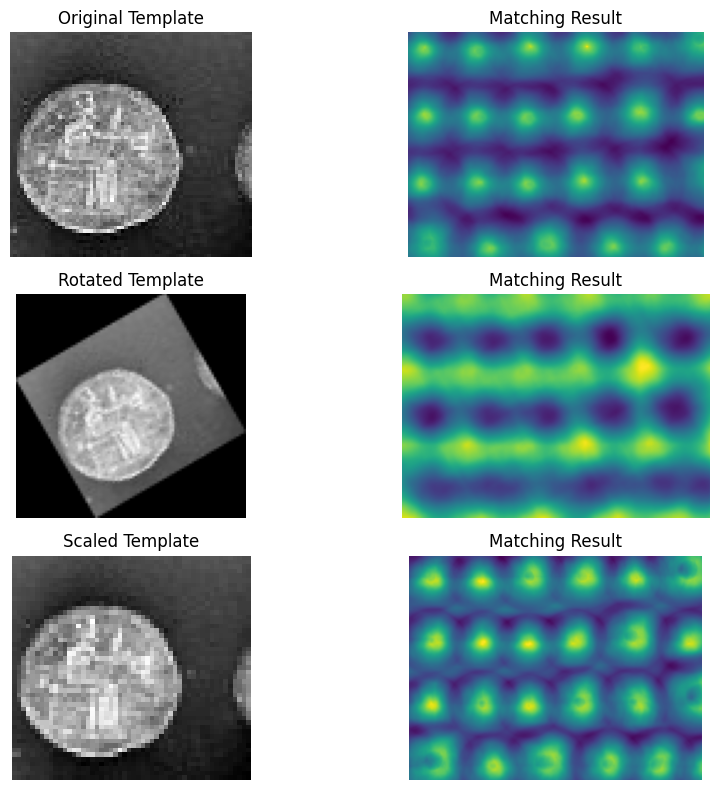

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, transform, feature

# Load citra dan template
image = data.coins()
template = image[15:80, 190:260]  # Template asli

# Rotasi dan skala template
template_rotated = transform.rotate(template, angle=30, resize=True)
template_scaled = transform.rescale(template, scale=0.75, anti_aliasing=True)

# Matching asli
result_original = feature.match_template(image, template)

# Matching setelah rotasi
result_rotated = feature.match_template(image, template_rotated)

# Matching setelah skala
result_scaled = feature.match_template(image, template_scaled)

# Visualisasi hasil
fig, axes = plt.subplots(3, 2, figsize=(10, 8))
titles = ["Original Template", "Rotated Template", "Scaled Template"]
templates = [template, template_rotated, template_scaled]
results = [result_original, result_rotated, result_scaled]

for i in range(3):
    axes[i, 0].imshow(templates[i], cmap='gray')
    axes[i, 0].set_title(titles[i])
    axes[i, 0].axis('off')

    axes[i, 1].imshow(results[i], cmap='viridis')
    axes[i, 1].set_title("Matching Result")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()
